In [1]:
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

DIR_REPO = Path.cwd().parents[1]
if str(DIR_REPO) not in sys.path:
    sys.path.insert(0, str(DIR_REPO))
print(DIR_REPO)

DIR_EXT = DIR_REPO / 'external'
if str(DIR_EXT) not in sys.path:
    sys.path.insert(0, str(DIR_EXT))

from external.sim_data_analyzer.batch_xr import (
    collect_batch_rates_from_spike_data,
    extract_batch_params_to_xr,
    extract_batch_spike_data_from_pkl,
    load_job_json
)
from external.sim_data_analyzer import netpyne_res_parse_utils as parse_utils
from external.sim_data_analyzer.xr_cache import load_or_run_xr
#from external.sim_data_analyzer.xr_spect import calc_xr_welch

/ddn/niknovikov19/repo/A1_OUinp


#### Parameters

In [2]:
EXP_LABEL = (
    'batch_rxbkg_unconn_state1_mech1/net_inpsur_rsweep_newsec_var_seed_pre/'
    'exp_pre_L4_post_L4_nseed_5_npre_6_t_5.0_20.0_tri_t0_5000_T_7500_rmax_10xbkg_500_ictrl_wmult_0.25_ee_0.5'
)
#CFG_PARAM_FIELDS = {"rxe": "rxe", "rxi": "rxi"}
CFG_PARAM_FIELDS = {'pop_pre': 'pop_pre', 'seed': 'seed_main'}

# Time interval of spike extraction
spike_t_limits = (1, None)

# Params of rate dynamics
dt_bin = 2e-3
tau_smooth = 10e-3

# Per-dimension chunk sizes for the rate dynamics nc-file
rate_chunks = {'pop_pre': 1, 'seed': 1}

dirpath_exp = DIR_REPO / 'exp_results' / EXP_LABEL
dirpath_cfg = dirpath_exp / 'cfg'
dirpath_pkl = dirpath_exp / 'pkl'

dirpath_work = dirpath_exp / 'combined'
dirpath_cache = dirpath_work / 'data_proc'
dirpath_res = dirpath_work / 'results'

os.makedirs(dirpath_cache, exist_ok=True)
os.makedirs(dirpath_res, exist_ok=True)

#### Extract batch grid coordinte from job cfg files

In [3]:
# Build the batch grid from the job cfg files.
job_idx_xr = extract_batch_params_to_xr(
    dirpath_cfg,
    cfg_param_fields=CFG_PARAM_FIELDS,
    fname_cfg_templ='cfg_*.json',
    job_pos_in_fname=1,
)
job_idx_xr

<xarray.DataArray 'job_id' (pop_pre: 6, seed: 5)> Size: 240B
array([[ 0,  6, 12, 18, 24],
       [ 1,  7, 13, 19, 25],
       [ 5, 11, 17, 23, 29],
       [ 2,  8, 14, 20, 26],
       [ 3,  9, 15, 21, 27],
       [ 4, 10, 16, 22, 28]])
Coordinates:
  * pop_pre  (pop_pre) object 48B 'ITP4' 'ITS4' 'NGF4' 'PV4' 'SOM4' 'VIP4'
  * seed     (seed) int64 40B 1000 1001 1002 1003 1004

#### Extract spikes from every job result pkl to a separate file

In [4]:
# Read first config
job_cfg_templ = 'cfg_{job:05d}_*.json'
cfg0 = load_job_json({'job_id': 0}, dirpath_cfg, job_cfg_templ)
cfg0 = cfg0['simConfig']

spike_t_limits = list(spike_t_limits)
if spike_t_limits[1] is None:
    spike_t_limits[1] = cfg0['duration'] / 1000

# Pops to use
pops_active = cfg0['subnet_params']['pops_active']
pops_pre_frz = [f'{pop}frz' for pop in cfg0['batch_par_info']['pops_pre']]
pops_used = pops_active + pops_pre_frz

# Extract one reusable SpikeData cache file per job.
dirpath_spikes = dirpath_cache / f'spikes_{spike_t_limits[0]}_{spike_t_limits[1]}'
os.makedirs(dirpath_spikes, exist_ok=True)
extract_batch_spike_data_from_pkl(
    job_idx_xr,
    dirpath_pkl,
    dirpath_spikes,
    fname_data_templ="data_{job:05d}_*.pkl",
    fname_spikes_templ="spikes_{job:05d}.npz",
    pop_names=pops_used,
    t_limits=spike_t_limits,
    combine=True,
    subtract_t0=False,
    ms=False,
)

--No graphics will be displayed.


numprocs=1


PosixPath('/ddn/niknovikov19/repo/A1_OUinp/exp_results/batch_rxbkg_unconn_state1_mech1/net_inpsur_rsweep_newsec_var_seed_pre/exp_pre_L4_post_L4_nseed_5_npre_6_t_5.0_20.0_tri_t0_5000_T_7500_rmax_10xbkg_500_ictrl_wmult_0.25_ee_0.5/combined/data_proc/spikes_1_20.0')

#### Collect firing rate dynamics from all jobs to a single xarray

In [5]:
rates_cache_path = dirpath_cache / f'rates_dt_{dt_bin}_tau_{tau_smooth}.nc'

# Collect the batch rates from the per-job SpikeData cache.
rates_xr = collect_batch_rates_from_spike_data(
    job_idx_xr, dirpath_spikes,
    fname_templ="spikes_{job:05d}.npz",
    t_limits=spike_t_limits,
    dt_bin=dt_bin, tau_smooth=tau_smooth,
    cache_path=rates_cache_path,
    lazy=True, load=False,
    chunks=rate_chunks,
    open_kwargs={"chunks": {}}
)
rates_xr

<xarray.DataArray '__xarray_dataarray_variable__' (pop_pre: 6, seed: 5,
                                                   pop: 12, time: 9500)> Size: 27MB
dask.array<open_dataset-__xarray_dataarray_variable__, shape=(6, 5, 12, 9500), dtype=float64, chunksize=(1, 1, 12, 9500), chunktype=numpy.ndarray>
Coordinates:
  * pop_pre  (pop_pre) <U4 96B 'ITP4' 'ITS4' 'NGF4' 'PV4' 'SOM4' 'VIP4'
  * seed     (seed) int64 40B 1000 1001 1002 1003 1004
  * pop      (pop) <U7 336B 'ITP4' 'ITS4' 'PV4' ... 'VIP4frz' 'NGF4frz'
  * time     (time) float64 76kB 1.0 1.002 1.004 1.006 ... 19.99 19.99 20.0 20.0
    job_id   (pop_pre, seed) int64 240B dask.array<chunksize=(6, 5), meta=np.ndarray>
Attributes:
    time_units:  s
    cache_info:  {'cache_id': '4d4a76184d0b', 'cache_version': 1, 'params': {...
    proc_steps:  [{'name': 'collect_batch_rates_from_spike_data', 'params': {...

In [10]:
pop_pre = 'PV4'

pops_post = [pop for pop in rates_xr.pop.values if 'frz' not in pop]

R_pre = rates_xr.sel(pop_pre=pop_pre, pop=f'{pop_pre}frz').compute()
R_post = rates_xr.sel(pop_pre=pop_pre, pop=pops_post).compute()

# Moving-average smoothing over time
smooth_win_s = 0.2
smooth_win_n = max(1, int(round(smooth_win_s / dt_bin)))
R_pre_sm = R_pre.rolling(time=smooth_win_n, center=True, min_periods=1).mean()
R_post_sm = R_post.rolling(time=smooth_win_n, center=True, min_periods=1).mean()

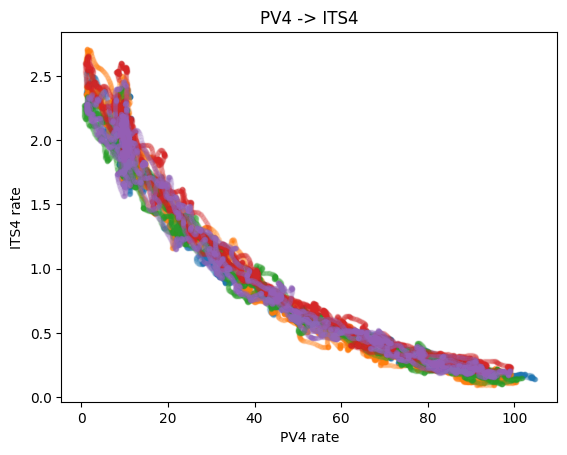

In [11]:
pop_post = 'ITS4'

plt.figure()
for seed in R_pre_sm.seed.values:
    plt.plot(R_pre_sm.sel(seed=seed),
            R_post_sm.sel(seed=seed).sel(pop=pop_post),
            '.', alpha=0.1)
plt.xlabel(f'{pop_pre} rate')
plt.ylabel(f'{pop_post} rate')
plt.title(f'{pop_pre} -> {pop_post}')
plt.show()